# Data Loader Preview

This notebook tests the custom `RAFDataset` and visualizes how the privacy filters affect the same image.

It is useful for:
- checking that the loader can read the dataset correctly;
- validating class labels and split sizes;
- previewing `blur`, `edges`, and `noise` transformations;
- inspecting a training batch before building the full pipeline.

In [1]:
from pathlib import Path
import random
import sys

import matplotlib.pyplot as plt
import pandas as pd

if Path.cwd().name == "notebooks":
    PROJECT_ROOT = Path.cwd().resolve().parent
else:
    PROJECT_ROOT = Path.cwd().resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data_loader import RAFDataset, create_data_loader

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_rows", 20)
pd.set_option("display.max_columns", 20)

In [2]:
dataset = RAFDataset(split="train", mode="none", return_metadata=True)

print(f"Data source: {dataset.data_source}")
print(f"Dataset root: {dataset.root_dir}")
print(f"Number of training samples: {len(dataset):,}")
print(f"Classes: {dataset.classes}")

Data source: folders
Dataset root: C:\Users\Tiago\Documents\GitHub\privacy-fer\data\raw\balanced-raf-db-dataset-7575-grayscale
Number of training samples: 30,023
Classes: ['surprise', 'fear', 'disgust', 'happy', 'sad', 'angry', 'neutral']


In [3]:
distribution_df = (
    pd.DataFrame.from_dict(dataset.get_class_distribution(), orient="index", columns=["count"])
    .rename_axis("class_name")
    .reset_index()
    .sort_values("count", ascending=False)
)

distribution_df

,class_name,count
0,surprise,4289
1,fear,4289
2,disgust,4289
3,happy,4289
4,sad,4289
5,angry,4289
6,neutral,4289


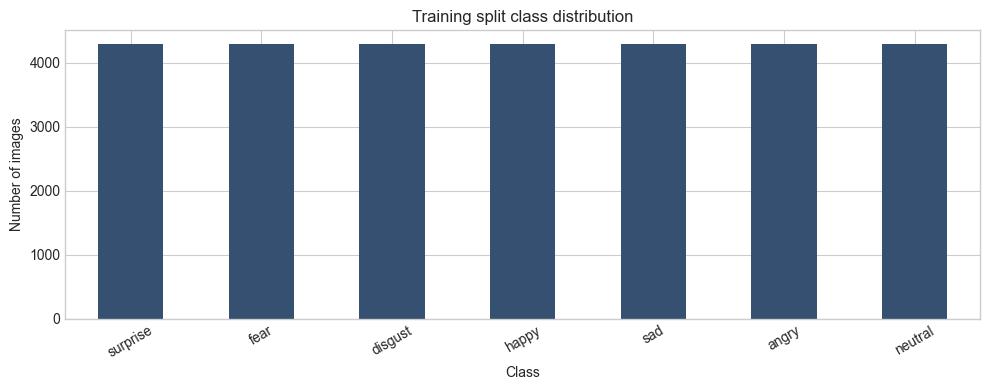

In [4]:
ax = distribution_df.plot(
    kind="bar",
    x="class_name",
    y="count",
    figsize=(10, 4),
    color="#355070",
    legend=False,
)
ax.set_title("Training split class distribution")
ax.set_xlabel("Class")
ax.set_ylabel("Number of images")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

In [5]:
privacy_configs = {
    "original": {"mode": "none", "intensity": 0},
    "blur": {"mode": "blur", "intensity": 5},
    "edges": {"mode": "edges", "intensity": 0},
    "noise": {"mode": "noise", "intensity": 250},
}

datasets = {
    name: RAFDataset(split="train", return_metadata=True, **config)
    for name, config in privacy_configs.items()
}

list(datasets.keys())

['original', 'blur', 'edges', 'noise']

In [6]:
sample_index = 0
sample = datasets["original"][sample_index]

print("File:", sample["file_name"])
print("Class:", sample["class_name"])
print("RAF label:", sample["raf_label"])
print("Target index:", sample["target"])
print("Split:", sample["split"])
print("Path:", sample["image_path"])

File: aug_100959.png
Class: angry
RAF label: 6
Target index: 5
Split: train
Path: C:\Users\Tiago\Documents\GitHub\privacy-fer\data\raw\balanced-raf-db-dataset-7575-grayscale\train\angry\aug_100959.png


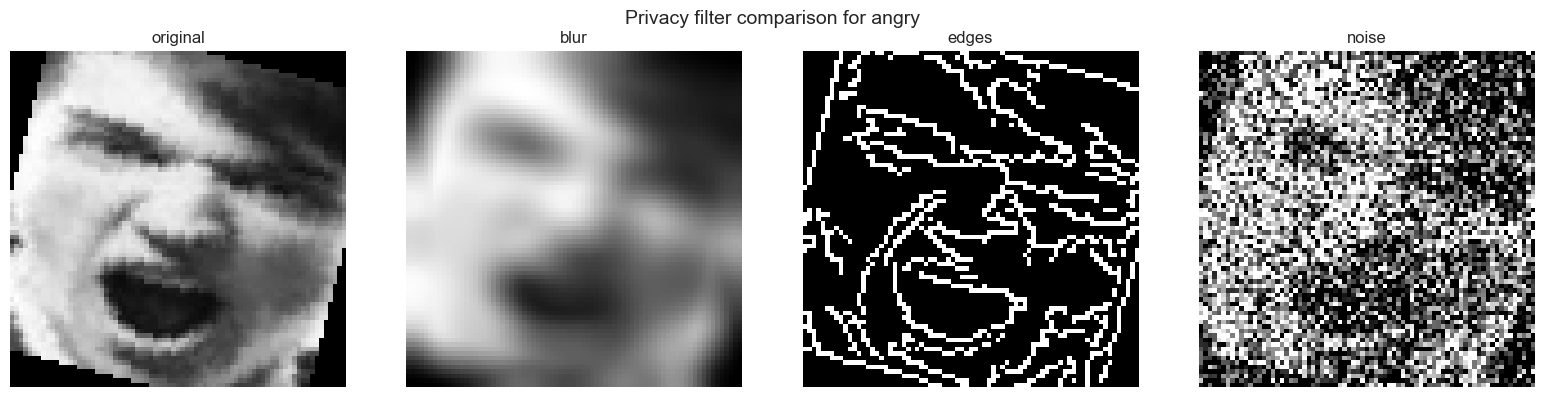

In [7]:
def tensor_to_image(tensor):
    image = tensor.detach().cpu().numpy()
    if image.ndim == 3 and image.shape[0] == 1:
        image = image[0]
    elif image.ndim == 3:
        image = image.transpose(1, 2, 0)
    return image


fig, axes = plt.subplots(1, len(datasets), figsize=(16, 4))

for ax, (name, ds) in zip(axes, datasets.items()):
    item = ds[sample_index]
    image = tensor_to_image(item["image"])
    ax.imshow(image, cmap="gray")
    ax.set_title(name)
    ax.axis("off")

fig.suptitle(f"Privacy filter comparison for {sample['class_name']}", fontsize=14)
plt.tight_layout()
plt.show()

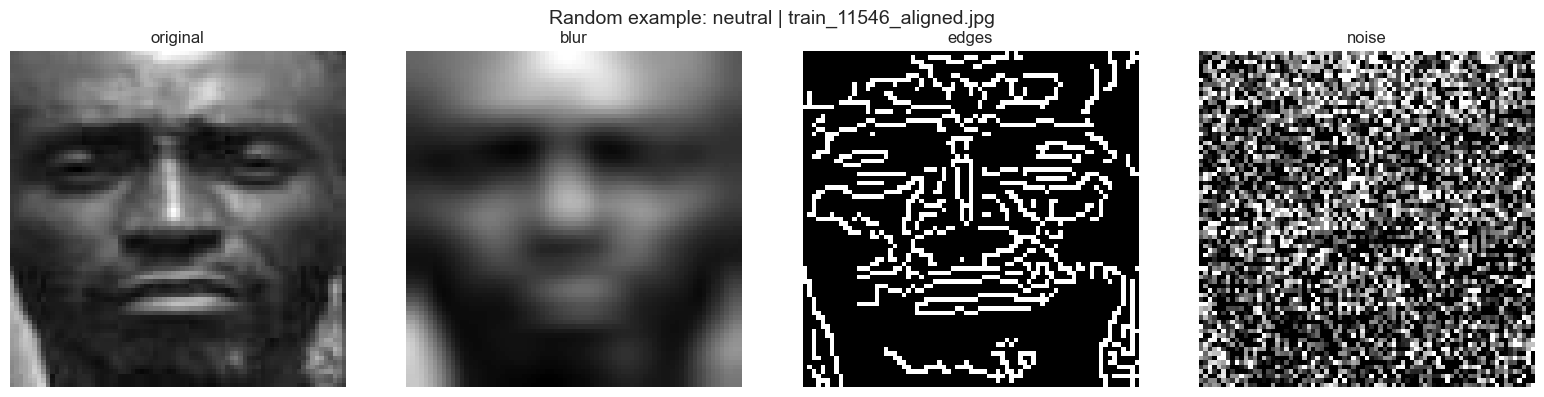

In [8]:
sample_index = random.randrange(len(dataset))
sample = datasets["original"][sample_index]

fig, axes = plt.subplots(1, len(datasets), figsize=(16, 4))

for ax, (name, ds) in zip(axes, datasets.items()):
    item = ds[sample_index]
    image = tensor_to_image(item["image"])
    ax.imshow(image, cmap="gray")
    ax.set_title(name)
    ax.axis("off")

fig.suptitle(
    f"Random example: {sample['class_name']} | {sample['file_name']}",
    fontsize=14,
)
plt.tight_layout()
plt.show()

In [9]:
train_loader = create_data_loader(
    split="train",
    batch_size=8,
    mode="blur",
    intensity=5,
    shuffle=True,
)

batch_images, batch_targets = next(iter(train_loader))

print("Batch images shape:", tuple(batch_images.shape))
print("Batch targets shape:", tuple(batch_targets.shape))
print("Batch dtype:", batch_images.dtype)
print("Unique targets in batch:", sorted(batch_targets.unique().tolist()))

Batch images shape: (8, 1, 75, 75)
Batch targets shape: (8,)
Batch dtype: torch.float32
Unique targets in batch: [0, 4, 5, 6]


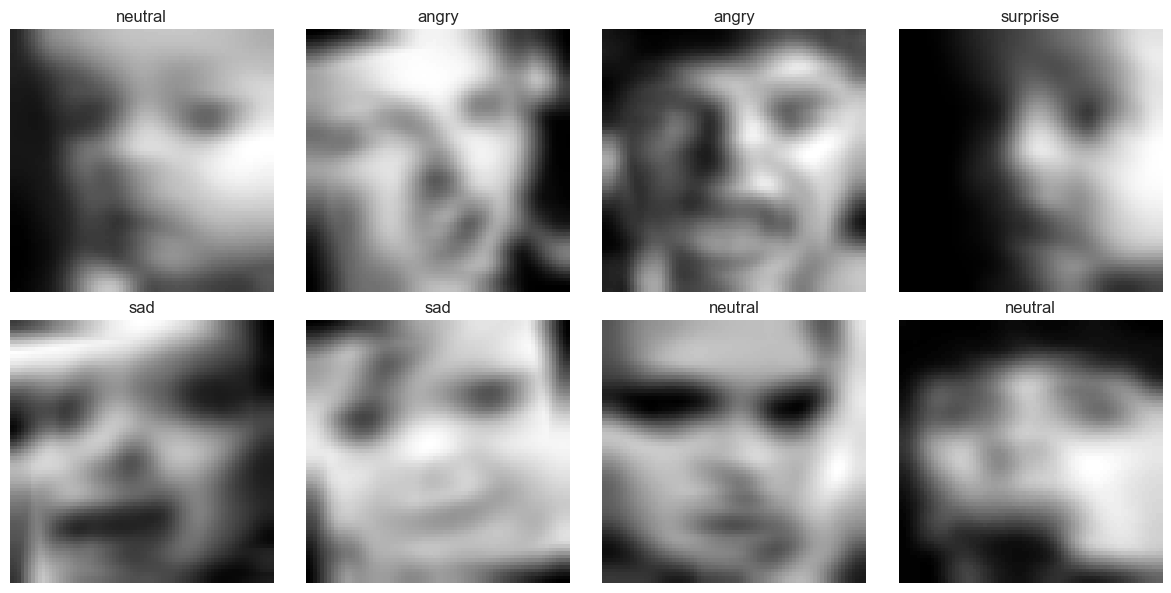

In [10]:
num_images = min(8, len(batch_images))
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()

for idx in range(num_images):
    image = batch_images[idx].squeeze(0).cpu().numpy()
    label_index = int(batch_targets[idx].item())
    label_name = dataset.classes[label_index]

    axes[idx].imshow(image, cmap="gray")
    axes[idx].set_title(label_name)
    axes[idx].axis("off")

for idx in range(num_images, len(axes)):
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

## Suggested Next Step

Once the previews look correct, the next natural step is to connect `RAFDataset` to a training script and compare model accuracy across different privacy settings.